In [44]:
import numpy as np
from numpy import cos, sin
import matplotlib.pyplot as plt

# Settings

In [45]:
# Example Save Code
# np.savez(
#     "3dorbit",
#     state = state,
#     time = time,
#     control = control,
#     time_c = time_c,
# )
# As long as the save file has state and time, this code will work. Edit the name to match the file of interest. Note that this code in its current state assumes that the state is in the nondimensionalized rotating frame.

file_name = "3dorbit"
path_modifier = "Standard_Cycler_Generation/"
reference_name = path_modifier + file_name + ".npz"
orbit = np.load(reference_name)

In [46]:
# Can set this differently to control exported file names
export_name = file_name + "_inertial"

# Set to 1 to export inertial states, time, and body positions. States are in km and km/s, time is in days, and the combined_state contains the Earth and Moon positions for each step, with the first three elements being the x, y, z positions of the Earth and the second three being the position coordinates for the Moon. The origin is at the system barycenter and the xy-plane is defined by the orbital plane of the Moon.
export = 0

In [47]:
mu = 1.2150584270572e-2

def t_to_day(t):
    return t*27.321661/2/np.pi

def day_to_t(t):
    return t*2*np.pi/27.321661

def x_to_dist(x):
    return x*384400

def unit_convert(x):
    x_new = np.zeros(np.shape(x))
    for i in range(np.shape(x)[1]):
        x_new[0:3,i] = x_to_dist(x[0:3,i])
        x_new[3:6,i] = day_to_t(x_to_dist(x[3:6,i]))/86400
    return x_new

def rotate_state(state, time_ang):
    state_inertial = np.zeros(np.shape(state))
    for i in range(np.shape(state)[1]):
        x, y, z, vx, vy, vz = state[:,i]
        theta = time_ang[i]
        state_inertial[:,i] = np.array([
            x*cos(theta) - y*sin(theta),
            x*sin(theta) + y*cos(theta),
            z,
            vx*cos(theta) - vy*sin(theta),
            vx*sin(theta) + vy*cos(theta),
            vz])
    return state_inertial

def rotate_state2(state, time_ang):
    state_inertial = np.zeros(np.shape(state))
    for i in range(np.shape(state)[1]):
        x, y, z, vx, vy, vz = state[:,i]
        theta = time_ang[i]
        state_inertial[:,i] = np.array([
            x*cos(theta) - y*sin(theta),
            x*sin(theta) + y*cos(theta),
            z,
            (vx - y)*cos(theta) - (vy + x)*sin(theta),
            (vx - y)*sin(theta) + (vy + x)*cos(theta),
            vz])
    return unit_convert(state_inertial)

In [48]:
state_rotating = unit_convert(orbit["state"])
xr, yr, zr, vxr, vyr, vzr = state_rotating
xraw, yraw, zraw, vxraw, vyraw, vzraw = orbit["state"]
time = orbit["time"]
state = rotate_state2(orbit["state"], time)
x, y, z, vx, vy, vz = state
t = t_to_day(time)

if "C_vals" in orbit:
    C_vals = orbit["C_vals"]
else:
    C_vals = None
if "hamiltonian" in orbit:
    hamiltonian = orbit["hamiltonian"]
else:
    hamiltonian = None

In [49]:
earth_state_rotating = x_to_dist(np.array([-mu, 0, 0]))
moon_state_rotating = x_to_dist(np.array([1 - mu, 0, 0]))
combined_state_rotating = np.concatenate((earth_state_rotating, moon_state_rotating)).reshape(-1,1)*np.ones((6,np.shape(state)[1]))
exr, eyr, ezr, mxr, myr, mzr = combined_state_rotating
combined_state = rotate_state(combined_state_rotating, time)
ex, ey, ez, mx, my, mz = combined_state

In [50]:
if export == 1:
    np.savez(
        export_name,
        state = state,
        time = t,
        combined_state = combined_state
    )

In [51]:
print("Orbit Period (nondimensional time)", time[-1])
print("Difference in final x position", xraw[0] - xraw[-1])
print("Difference in final y position", yraw[0] - yraw[-1])
print("Difference in final z position", zraw[0] - zraw[-1])
print("Difference in final x velocity", vxraw[0] - vxraw[-1])
print("Difference in final y velocity", vyraw[0] - vyraw[-1])
print("Difference in final z velocity", vzraw[0] - vzraw[-1])
if C_vals is not None:
    print("Maximum Jacobi Constant Deviation", np.ptp(C_vals))
if hamiltonian is not None:
    print("Maximum Hamiltonian Deviation", np.ptp(hamiltonian))

Orbit Period (nondimensional time) 10.291689395941015
Difference in final x position 0.0
Difference in final y position 0.0
Difference in final z position 0.0
Difference in final x velocity -2.6748991139124943e-06
Difference in final y velocity -2.0483614804334138e-14
Difference in final z velocity 0.0
Maximum Jacobi Constant Deviation 1.8987433847428292e-10
Maximum Hamiltonian Deviation 1.8295987122202266e-07


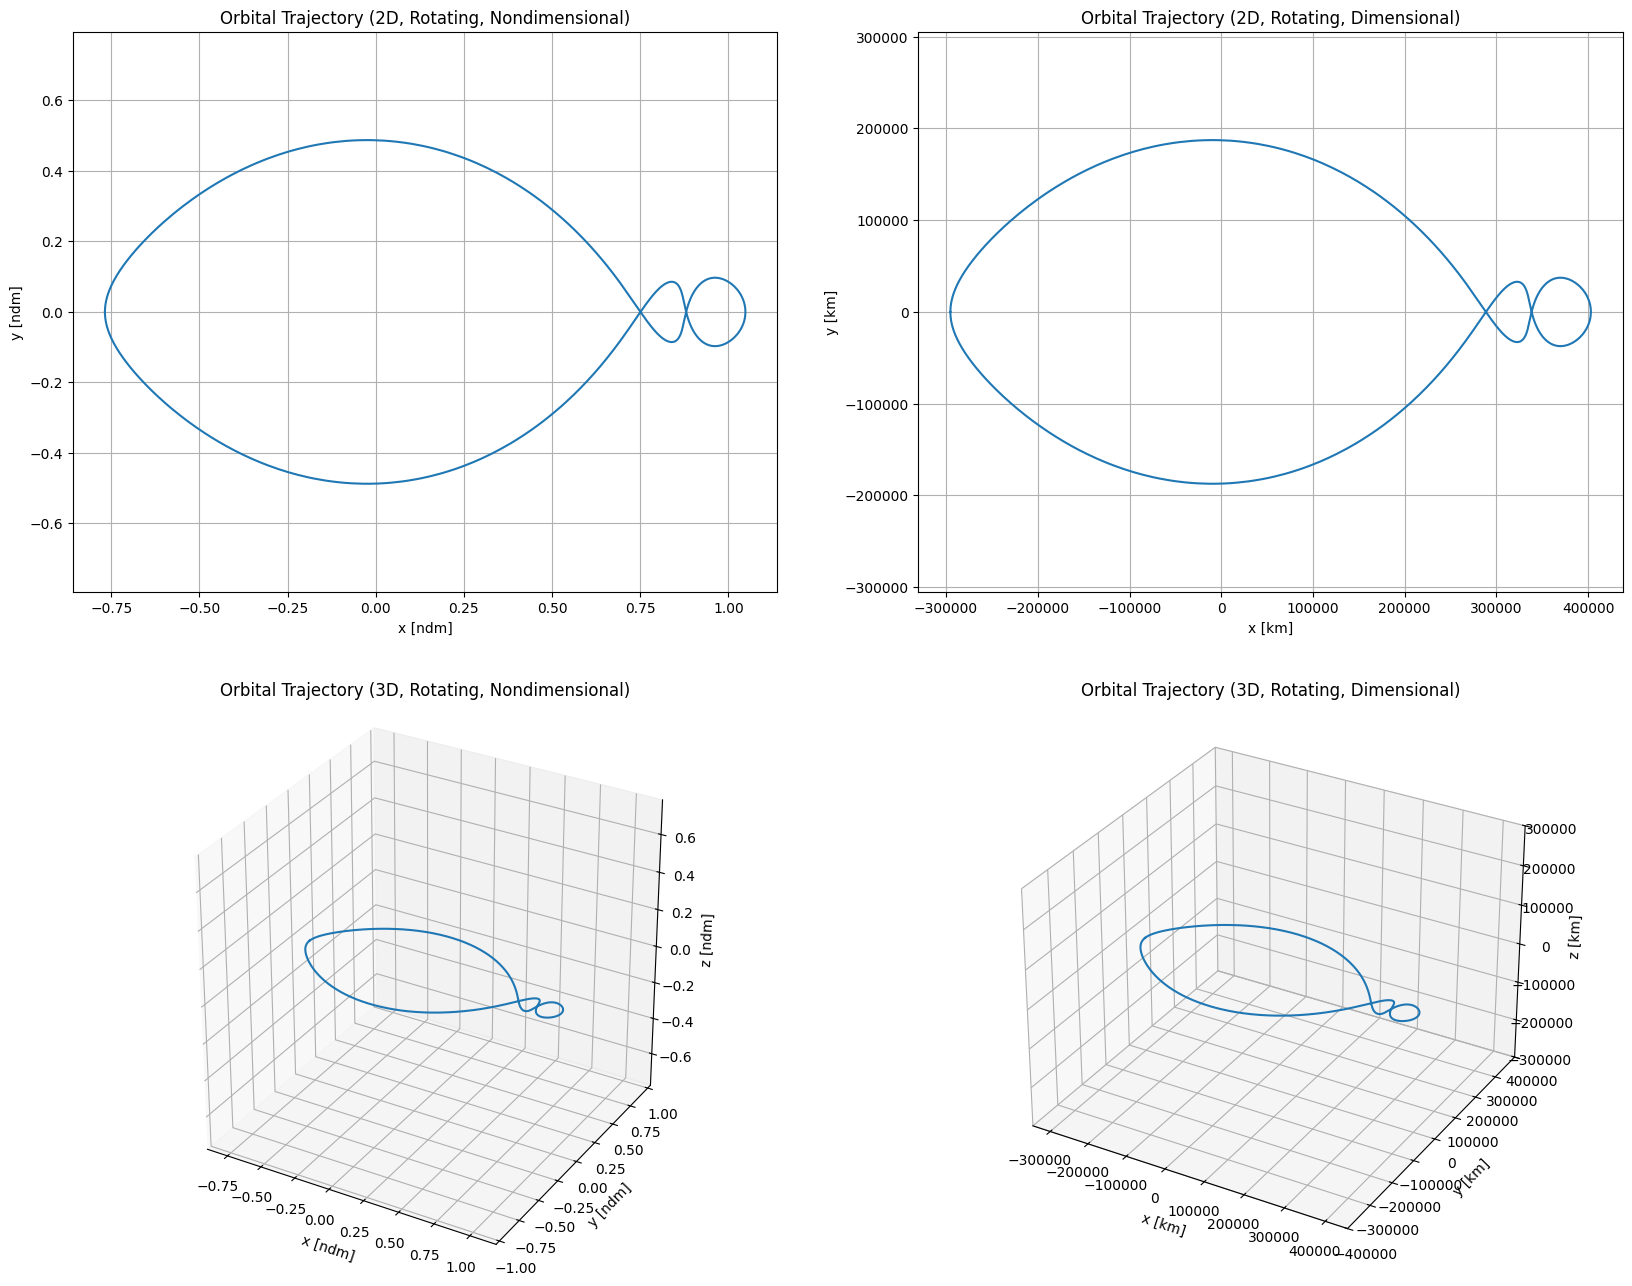

In [52]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(xraw, yraw)
ax1.axis("equal")
ax1.set_xlabel("x [ndm]")
ax1.set_ylabel("y [ndm]")
ax1.set_title("Orbital Trajectory (2D, Rotating, Nondimensional)")
ax1.grid(True)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(xr, yr)
ax2.axis("equal")
ax2.set_xlabel("x [km]")
ax2.set_ylabel("y [km]")
ax2.set_title("Orbital Trajectory (2D, Rotating, Dimensional)")
ax2.grid(True)

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot(xraw, yraw, zraw)
ax3.set_aspect("equal", adjustable='datalim')
ax3.set_box_aspect((1,1,1))
ax3.set_xlabel("x [ndm]")
ax3.set_ylabel("y [ndm]")
ax3.set_zlabel("z [ndm]")
ax3.set_title("Orbital Trajectory (3D, Rotating, Nondimensional)")
ax3.grid(True)

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot(xr, yr, zr)
ax4.set_aspect("equal", adjustable='datalim')
ax4.set_xlabel("x [km]")
ax4.set_ylabel("y [km]")
ax4.set_zlabel("z [km]")
ax4.set_title("Orbital Trajectory (3D, Rotating, Dimensional)")
ax4.grid(True)

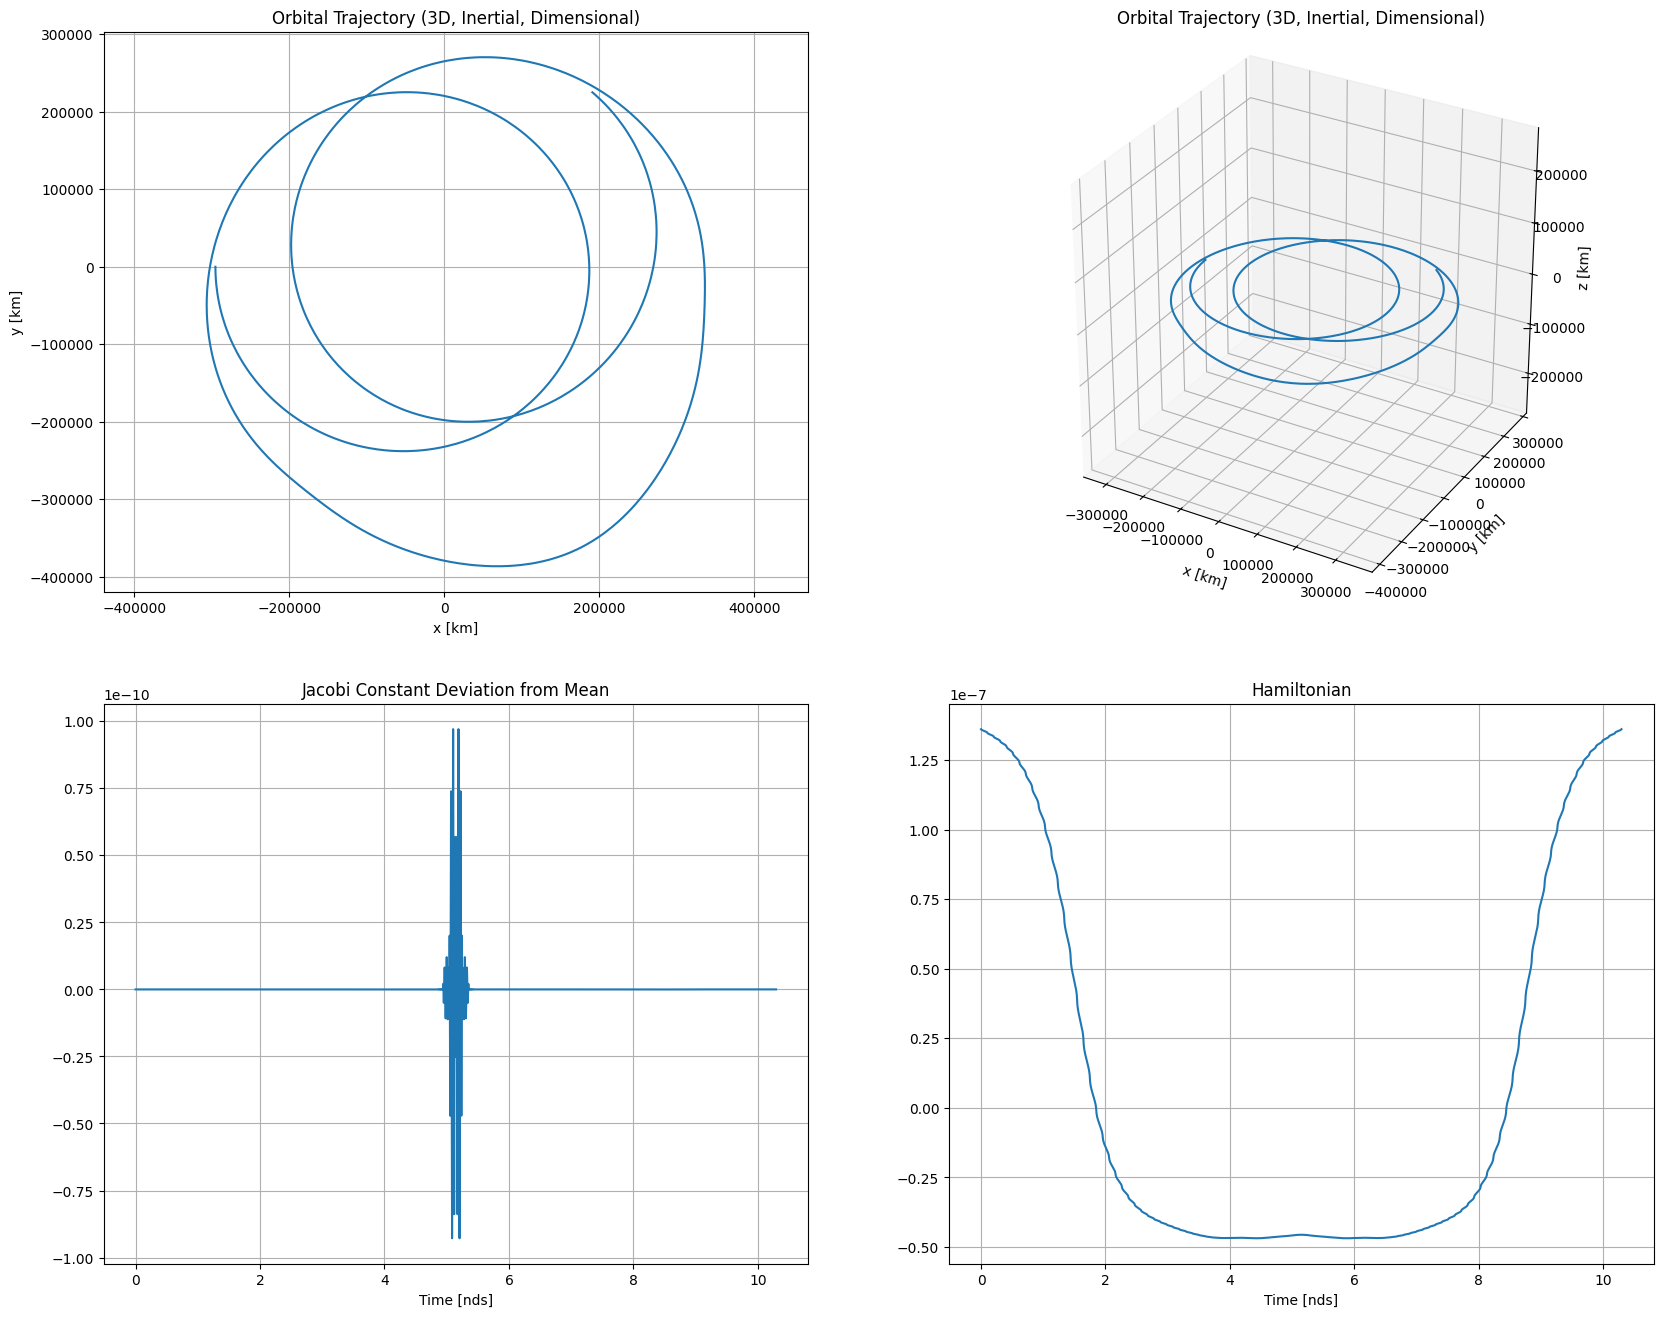

In [54]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(x, y)
ax1.axis("equal")
ax1.set_xlabel("x [km]")
ax1.set_ylabel("y [km]")
ax1.set_title("Orbital Trajectory (3D, Inertial, Dimensional)")
ax1.grid(True)

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot(x, y, z)
ax2.set_aspect("equal", adjustable='datalim')
ax2.set_box_aspect((1,1,1))
ax2.set_xlabel("x [km]")
ax2.set_ylabel("y [km]")
ax2.set_zlabel("z [km]")
ax2.set_title("Orbital Trajectory (3D, Inertial, Dimensional)")
ax2.grid(True)

if C_vals is not None:
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(time, C_vals - np.mean(C_vals))
    ax3.set_xlabel("Time [nds]")
    ax3.set_title("Jacobi Constant Deviation from Mean")
    ax3.grid(True)

if hamiltonian is not None:
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(time, hamiltonian)
    ax4.set_xlabel("Time [nds]")
    ax4.set_title("Hamiltonian")
    ax4.grid(True)